# 04 — Modeling

Train Logistic Regression, Random Forest, and XGBoost on the processed data
from `03_feature_engineering.ipynb`, using proper methodology: cross-validate
on train for stability, select the best model using the **validation** set,
then touch the **test** set exactly once for the final reported numbers.

Structure:
1. Load processed data
2. Train all three models
3. Cross-validation on training set (stability check)
4. Validation set evaluation and model comparison
5. Select best model
6. Final test set evaluation (once only)
7. Save the best model

**Why the val/test split matters here:** if we picked the "best" model by
looking at test set performance, we'd be implicitly tuning our model choice
to the test set, making the final reported numbers optimistic. Validation
set decides which model wins; test set only measures how well that already-
chosen model generalizes.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import pandas as pd

from src.utils import load_config, set_seed, resolve_path
from src.train import (
    train_logistic_regression, train_random_forest, train_xgboost,
    cross_validate_model, save_model,
)
from src.evaluate import evaluate_model, plot_confusion_matrix, plot_roc_curves, build_comparison_table

config = load_config()
set_seed(config["random_seed"])
FIG_DIR = resolve_path(config["paths"]["figures_dir"])
FIG_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR = resolve_path(config["paths"]["models_dir"])
MODELS_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load Processed Data

Loading the exact train/val/test splits saved by notebook 03 — not re-running
the split here, so there's no risk of accidentally using a different random
state or re-fitting the scaler on different data.

In [2]:
processed_dir = resolve_path("data/processed")

X_train = pd.read_parquet(processed_dir / "X_train.parquet")
X_val = pd.read_parquet(processed_dir / "X_val.parquet")
X_test = pd.read_parquet(processed_dir / "X_test.parquet")
y_train = pd.read_parquet(processed_dir / "y_train.parquet").iloc[:, 0]
y_val = pd.read_parquet(processed_dir / "y_val.parquet").iloc[:, 0]
y_test = pd.read_parquet(processed_dir / "y_test.parquet").iloc[:, 0]

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Train class balance:\n{y_train.value_counts(normalize=True)}")

Train: (160631, 27), Val: (22948, 27), Test: (45895, 27)
Train class balance:
Diabetes_binary
0    0.847053
1    0.152947
Name: proportion, dtype: float64


## 2. Train All Three Models

Each model handles the class imbalance in its own native way rather than
relying on a single external SMOTE step: Logistic Regression and Random
Forest use `class_weight='balanced'`, XGBoost uses `scale_pos_weight`
computed from the actual train split (see `src/train.py`). This avoids the
risk of synthetic-sample artifacts from oversampling and keeps each model's
imbalance handling transparent and native to that model's own hyperparameters.

In [3]:
logreg = train_logistic_regression(X_train, y_train, config["models"]["logistic_regression"])
rf = train_random_forest(X_train, y_train, config["models"]["random_forest"])
xgb = train_xgboost(X_train, y_train, config["models"]["xgboost"])

models = {
    "Logistic Regression": logreg,
    "Random Forest": rf,
    "XGBoost": xgb,
}

2026-09-16 15:19:45 | src.train | INFO | Logistic Regression trained.
2026-09-16 15:19:55 | src.train | INFO | Random Forest trained.
2026-09-16 15:19:58 | src.train | INFO | XGBoost trained (scale_pos_weight=5.54).


## 3. Cross-Validation on Training Set

Before trusting a single validation-set score, check each model's stability
across 5 folds of the training data. A model with a high mean but also high
std is less trustworthy than one with a slightly lower mean but tight std —
this matters more than it might seem given the class imbalance.

In [4]:
cv_results = {}
for name, model in models.items():
    result = cross_validate_model(model, X_train, y_train, cv=5, random_state=config["random_seed"])
    cv_results[name] = result
    print(f"{name}: ROC-AUC = {result['mean']:.4f} +/- {result['std']:.4f}")

2026-09-16 15:20:07 | src.train | INFO | 5-fold CV ROC-AUC: mean=0.8073, std=0.0046


Logistic Regression: ROC-AUC = 0.8073 +/- 0.0046


2026-09-16 15:20:41 | src.train | INFO | 5-fold CV ROC-AUC: mean=0.8098, std=0.0041


Random Forest: ROC-AUC = 0.8098 +/- 0.0041


2026-09-16 15:20:53 | src.train | INFO | 5-fold CV ROC-AUC: mean=0.8114, std=0.0041


XGBoost: ROC-AUC = 0.8114 +/- 0.0041


## 4. Validation Set Evaluation

This is the comparison that decides which model wins — test set stays
untouched until section 6.

In [5]:
val_metrics = []
for name, model in models.items():
    metrics = evaluate_model(model, X_val, y_val, model_name=name)
    val_metrics.append(metrics)

val_comparison = build_comparison_table(val_metrics)
val_comparison


=== Logistic Regression ===
              precision    recall  f1-score   support

 No Diabetes       0.94      0.71      0.81     19438
    Diabetes       0.32      0.76      0.45      3510

    accuracy                           0.72     22948
   macro avg       0.63      0.74      0.63     22948
weighted avg       0.85      0.72      0.76     22948


=== Random Forest ===
              precision    recall  f1-score   support

 No Diabetes       0.94      0.73      0.82     19438
    Diabetes       0.33      0.74      0.46      3510

    accuracy                           0.73     22948
   macro avg       0.63      0.73      0.64     22948
weighted avg       0.85      0.73      0.76     22948


=== XGBoost ===
              precision    recall  f1-score   support

 No Diabetes       0.94      0.71      0.81     19438
    Diabetes       0.32      0.76      0.45      3510

    accuracy                           0.72     22948
   macro avg       0.63      0.74      0.63     22948
weigh

,accuracy,precision,recall,f1,roc_auc
model,,,,,
Logistic Regression,0.720,0.323,0.757,0.453,0.813
Random Forest,0.729,0.329,0.742,0.455,0.816
XGBoost,0.719,0.323,0.764,0.454,0.820


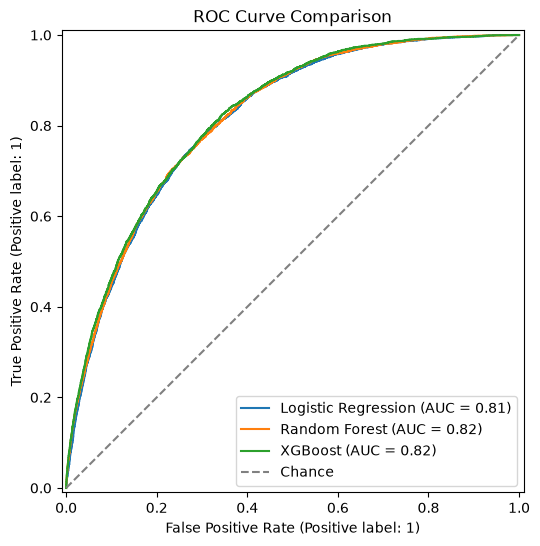

In [6]:
plot_roc_curves(models, X_val, y_val, save_path=str(FIG_DIR / "12_roc_curves_validation.png"))
import matplotlib.pyplot as plt
plt.show()

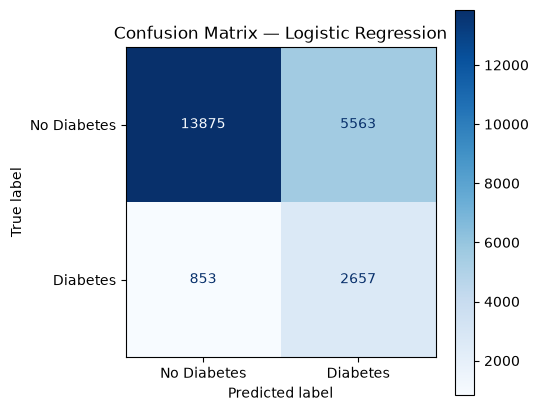

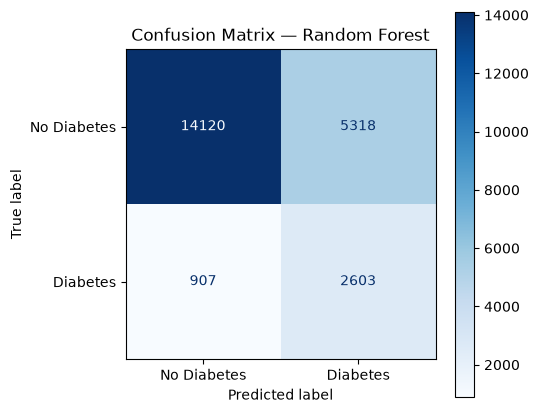

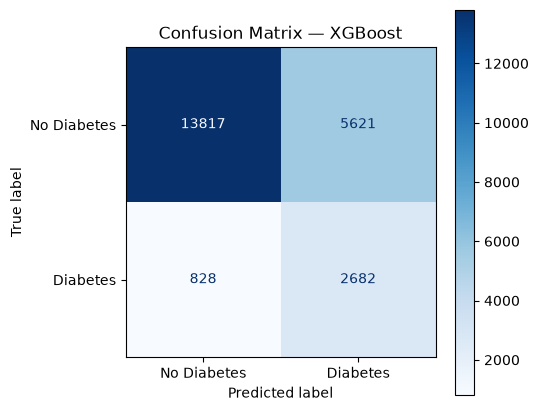

In [7]:
for name, model in models.items():
    plot_confusion_matrix(model, X_val, y_val, model_name=name, save_path=str(FIG_DIR / f"13_confusion_matrix_{name.replace(' ', '_').lower()}.png"))
    plt.show()

## 5. Select Best Model

Selecting by ROC-AUC on the validation set — a good default for an imbalanced
binary problem since it's threshold-independent, though the confusion matrices
above are worth reviewing too: for a screening use case, recall on the
diabetic class (catching true positives) may matter more than raw ROC-AUC
depending on the actual deployment context. Change the selection rule below
if a different metric matters more for your use case.

In [8]:
best_model_name = val_comparison["roc_auc"].idxmax()
best_model = models[best_model_name]
print(f"Best model on validation ROC-AUC: {best_model_name} ({val_comparison.loc[best_model_name, 'roc_auc']:.4f})")

Best model on validation ROC-AUC: XGBoost (0.8200)


## 6. Final Test Set Evaluation (Once Only)

This is the one and only time the test set is used. These are the numbers
that go in the README's Model Performance table.

In [9]:
test_metrics = evaluate_model(best_model, X_test, y_test, model_name=best_model_name)
test_metrics_df = pd.DataFrame([test_metrics]).set_index("model").round(3)
test_metrics_df


=== XGBoost ===
              precision    recall  f1-score   support

 No Diabetes       0.95      0.70      0.80     38876
    Diabetes       0.32      0.78      0.45      7019

    accuracy                           0.71     45895
   macro avg       0.63      0.74      0.63     45895
weighted avg       0.85      0.71      0.75     45895



,accuracy,precision,recall,f1,roc_auc
model,,,,,
XGBoost,0.712,0.318,0.777,0.452,0.816


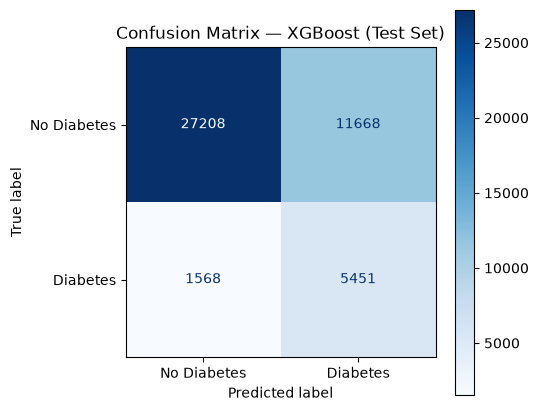

In [10]:
plot_confusion_matrix(best_model, X_test, y_test, model_name=f"{best_model_name} (Test Set)", save_path=str(FIG_DIR / "14_confusion_matrix_test_final.png"))
plt.show()

**Note on false negatives:** for a diabetes screening context, a false
negative (predicting 'no diabetes' for someone who has it) is generally more
costly than a false positive (an unnecessary follow-up test). Check the
confusion matrix above — if false negatives are still high, consider
adjusting the classification threshold (currently the default 0.5) to trade
some precision for recall, rather than treating 0.5 as fixed.

## 7. Save the Best Model

In [11]:
import json

model_filename = f"best_model_{best_model_name.replace(' ', '_').lower()}.joblib"
save_model(best_model, str(MODELS_DIR / model_filename))
save_model(best_model, str(MODELS_DIR / "best_model.joblib"))  # stable name for 05/06 to load

metadata = {
    "best_model_name": best_model_name,
    "model_file": model_filename,
    "validation_metrics": val_comparison.loc[best_model_name].to_dict(),
    "test_metrics": test_metrics,
    "cv_mean_roc_auc": cv_results[best_model_name]["mean"],
    "cv_std_roc_auc": cv_results[best_model_name]["std"],
}
with open(MODELS_DIR / "model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2, default=float)

print(f"Saved best model ({best_model_name}) to models/best_model.joblib")
print("Saved metadata to models/model_metadata.json")
print(json.dumps(metadata, indent=2, default=float))

2026-09-16 15:20:57 | src.train | INFO | Model saved to C:\diabetes-risk-prediction\models\best_model_xgboost.joblib
2026-09-16 15:20:57 | src.train | INFO | Model saved to C:\diabetes-risk-prediction\models\best_model.joblib


Saved best model (XGBoost) to models/best_model.joblib
Saved metadata to models/model_metadata.json
{
  "best_model_name": "XGBoost",
  "model_file": "best_model_xgboost.joblib",
  "validation_metrics": {
    "accuracy": 0.719,
    "precision": 0.323,
    "recall": 0.764,
    "f1": 0.454,
    "roc_auc": 0.82
  },
  "test_metrics": {
    "model": "XGBoost",
    "accuracy": 0.711602571086175,
    "precision": 0.31841813190022783,
    "recall": 0.7766063541815074,
    "f1": 0.45165299527715635,
    "roc_auc": 0.8158261190602826
  },
  "cv_mean_roc_auc": 0.8114089725776468,
  "cv_std_roc_auc": 0.004134417996165178
}


Next: `05_interpretability_shap.ipynb` loads `models/best_model.joblib` and
explains what's driving its predictions.